<a href="https://colab.research.google.com/github/aaron123908/Module2/blob/main/Clustering_Exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



*   Aaron Ryoo
*   **Business Understanding:** Main objective is to sort the different customers into groups to understand the customer base and make targeted decisions. With clustering, the bank can identify customer groups with similar buying behavior, market towards customers better, and improve management of portfolio through understanding of which customers take small or big loans.
*   **Data Understanding:** The dataset contains 700 rows along with 10 variables (age, sex, job, housing, etc.). The savings accounts and checking accounts contain some missing values. People who loan large amounts are more likely to be male and usually have longer durations.


In [4]:
#This cell loads the bank.xlsx file into a dataframe and creates a subset containing three numeric fields: Age, loan amount, and duration.

import pandas as pd

df = pd.read_excel("bank.xlsx")

subset_df = df[["Age", "loan amount", "Duration"]]

subset_df.head()

/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


,Age,loan amount,Duration
0,67,1169,6
1,22,5951,48
2,49,2096,12
3,45,7882,42
4,53,4870,24


In [5]:
# This cell standardizes the numeric subset data so that Age, loan amount, and Duration are on the same scale.

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

subset_scaled = scaler.fit_transform(subset_df)

subset_scaled[:5]

array([[ 2.80037426, -0.73927893, -1.19411343],
       [-1.17778887,  1.01663258,  2.22861591],
       [ 1.20910901, -0.39889207, -0.70515209],
       [ 0.85549451,  1.72568008,  1.73965457],
       [ 1.56272351,  0.61969817,  0.27277057]])

In [6]:
# This cell performs K-Means clustering on the standardized data using four clusters and stores the labels.

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(subset_scaled)

subset_df["Cluster"] = clusters

subset_df.head()

/tmp/ipykernel_3792/1007765825.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_df["Cluster"] = clusters


,Age,loan amount,Duration,Cluster
0,67,1169,6,1
1,22,5951,48,0
2,49,2096,12,1
3,45,7882,42,2
4,53,4870,24,1


In [7]:
# This cell calculates the Silhouette Score to evaluate the quality of the 4-cluster model.

from sklearn.metrics import silhouette_score

sil_score = silhouette_score(subset_scaled, clusters)

print("Silhouette Score:", round(sil_score, 4))

Silhouette Score: 0.3465


### Comment on Model Quality

For this model, the Silhouette Score is **0.35**, which indicates decent clustering quality. This means the four clusters are reasonably distinct, but has some overlap between customer groups as the score is closer to 0.



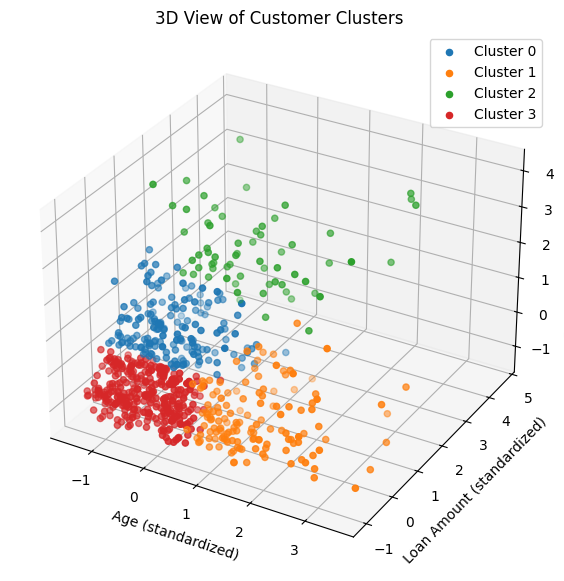

In [8]:
# The cell creates a 3D scatter plot of the four customer clusters using Age, loan amount, and Duration.

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

for i in range(4):
    ax.scatter(
        subset_scaled[clusters == i, 0],
        subset_scaled[clusters == i, 1],
        subset_scaled[clusters == i, 2],
        label=f"Cluster {i}"
    )

ax.set_xlabel("Age (standardized)")
ax.set_ylabel("Loan Amount (standardized)")
ax.set_zlabel("Duration (standardized)")
ax.set_title("3D View of Customer Clusters")

ax.legend()

plt.show()

In [9]:
# This cell summarizes the results by calculating the average age, loan amount, and duration for each cluster

cluster_summary = subset_df.groupby("Cluster")[["Age", "loan amount", "Duration"]].mean()

cluster_summary

,Age,loan amount,Duration
Cluster,,,
0,30.596386,4380.301205,29.349398
1,52.391608,2206.923077,15.468531
2,36.859375,9667.093750,43.812500
3,29.957187,1731.553517,13.972477


## Interpretation of Results

- **Cluster 0:** Appears to include customers with relatively lower loan amounts and shorter loan durations, which suggests smaller and short-term borrowing behavior.
- **Cluster 1:** Here we have the customer group with higher loan amounts and longer loan durations. Indicates that this group has many customers who may be on the richer side.
- **Cluster 2:** Customers in this group tend be older, borrow a moderate amount, and have moderate loan durations. Seems to be more balanced in terms of customer segment.
- **Cluster 3:** Includes a pool of younger customers with loan amounts that vary wildly.Shorter loan duration is consistent which is less compared to other clusters such as 1.